# Wood Surface Defects Dataset — Exploratory Analysis

Dataset: [`iluvvatar/wood_surface_defects`](https://huggingface.co/datasets/iluvvatar/wood_surface_defects) (Hugging Face),
converted to YOLO detection format (`images/` + `labels/` + `data.yaml`) by
`prepare_wood_defects.py` for training the `yolov8_CDC` model in this repo.

This notebook covers **exploratory data analysis and dataset statistics only**
(no model training/inference) — class balance, bounding-box geometry, image
quality, and object-scale analysis to inform training choices (`imgsz`,
augmentation, class weighting) for the `run_all.sh` pipeline.


In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import yaml
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)


In [2]:
DATASET_DIR = Path("wood_defects_dataset")
with open(DATASET_DIR / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = [data_cfg["names"][i] for i in sorted(data_cfg["names"])]
NUM_CLASSES = len(CLASS_NAMES)
SPLITS = ["train", "val"]

print(f"Dataset root: {DATASET_DIR.resolve()}")
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")


Dataset root: /home/drking/Documents/Diplomka/vevees-defects/YOLOV8-CDC/wood_defects_dataset
Classes (10): ['Blue_Stain', 'Crack', 'Dead_Knot', 'Knot_missing', 'Live_Knot', 'Marrow', 'Quartzity', 'knot_with_crack', 'overgrown', 'resin']


## 1. Dataset integrity

Confirm every image has a matching label file (and vice versa) before trusting any stats below.

In [3]:
def list_files(split, kind):
    return sorted((DATASET_DIR / kind / split).glob("*"))

summary = []
for split in SPLITS:
    imgs = list_files(split, "images")
    lbls = list_files(split, "labels")
    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}
    summary.append({
        "split": split,
        "n_images": len(imgs),
        "n_labels": len(lbls),
        "images_without_labels": len(img_stems - lbl_stems),
        "labels_without_images": len(lbl_stems - img_stems),
    })

integrity_df = pd.DataFrame(summary)
integrity_df


,split,n_images,n_labels,images_without_labels,labels_without_images
0,train,18248,18248,0,0
1,val,2028,2028,0,0


## 2. Parse all bounding boxes into a long-form table

Each row is one bounding box: `(split, image_id, class, xc, yc, w, h)` in YOLO-normalized coordinates ([0, 1]).

In [4]:
def parse_labels(split):
    rows = []
    label_dir = DATASET_DIR / "labels" / split
    for lbl_path in sorted(label_dir.glob("*.txt")):
        text = lbl_path.read_text().strip()
        if not text:
            continue
        for line in text.splitlines():
            cls_idx, xc, yc, w, h = line.split()
            rows.append({
                "split": split,
                "image_id": lbl_path.stem,
                "class_idx": int(cls_idx),
                "class_name": CLASS_NAMES[int(cls_idx)],
                "xc": float(xc), "yc": float(yc),
                "w": float(w), "h": float(h),
            })
    return rows

boxes = pd.DataFrame(sum((parse_labels(s) for s in SPLITS), []))
boxes["area"] = boxes["w"] * boxes["h"]
boxes["aspect_ratio"] = boxes["w"] / boxes["h"]

n_empty_labels = sum(
    1 for s in SPLITS for p in list_files(s, "labels") if p.stat().st_size == 0
)
print(f"Total boxes parsed: {len(boxes):,}")
print(f"Empty label files (images with zero defects): {n_empty_labels:,}")
boxes.head()


Total boxes parsed: 43,974
Empty label files (images with zero defects): 1,992


,split,image_id,class_idx,class_name,xc,yc,w,h,area,aspect_ratio
0,train,100000000,6,Quartzity,0.471965,0.648438,0.064643,0.703125,0.045452,0.091937
1,train,100000000,4,Live_Knot,0.532321,0.945312,0.047500,0.033203,0.001577,1.430594
2,train,100000000,4,Live_Knot,0.546964,0.150391,0.052500,0.058593,0.003076,0.896011
3,train,100000002,5,Marrow,0.457857,0.262207,0.051428,0.524414,0.026970,0.098068
4,train,100000002,4,Live_Knot,0.417857,0.400390,0.044286,0.082031,0.003633,0.539869


## 3. Class distribution

How many boxes of each defect class, per split.

In [5]:
class_counts = (
    boxes.groupby(["split", "class_name"]).size()
    .unstack("split").reindex(CLASS_NAMES).fillna(0).astype(int)
)
class_counts["total"] = class_counts.sum(axis=1)
class_counts = class_counts.sort_values("total", ascending=False)
class_counts


split,train,val,total
class_name,,,
Live_Knot,19028,2196,21224
Dead_Knot,10797,1188,11985
resin,3143,312,3455
knot_with_crack,2057,219,2276
Crack,1929,240,2169
Marrow,1062,119,1181
Quartzity,964,111,1075
Knot_missing,442,61,503
Blue_Stain,91,5,96


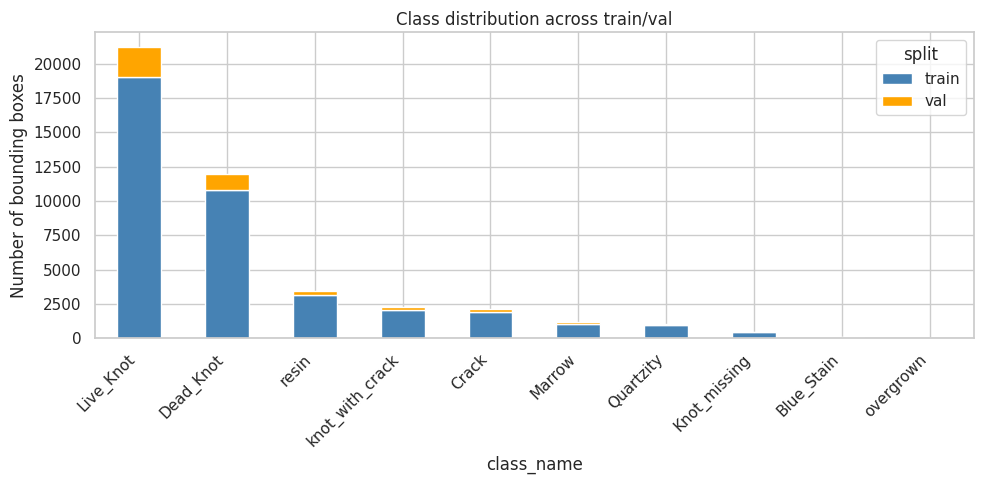

Most common class:  Live_Knot        (21,224 boxes)
Least common class: overgrown        (10 boxes)
Imbalance ratio (max/min): 2122.4x


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
class_counts[SPLITS].plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "orange"])
ax.set_ylabel("Number of bounding boxes")
ax.set_title("Class distribution across train/val")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

counts_total = class_counts["total"]
print(f"Most common class:  {counts_total.idxmax():<16} ({counts_total.max():,} boxes)")
print(f"Least common class: {counts_total.idxmin():<16} ({counts_total.min():,} boxes)")
print(f"Imbalance ratio (max/min): {counts_total.max() / counts_total.min():.1f}x")


### Train/val stratification check

Compares each class's *share* of boxes within train vs. within val — large gaps would mean the split
isn't representative and validation metrics may be misleading for rare classes.


In [7]:
props = class_counts[SPLITS].div(class_counts[SPLITS].sum(axis=0), axis=1) * 100
props.columns = [f"{c} %" for c in props.columns]
props["abs diff (pp)"] = (props.iloc[:, 0] - props.iloc[:, 1]).abs()
props.round(2).sort_values("abs diff (pp)", ascending=False)


,train %,val %,abs diff (pp)
class_name,,,
Live_Knot,48.14,49.34,1.19
resin,7.95,7.01,0.94
Dead_Knot,27.32,26.69,0.63
Crack,4.88,5.39,0.51
knot_with_crack,5.20,4.92,0.28
Knot_missing,1.12,1.37,0.25
Blue_Stain,0.23,0.11,0.12
Quartzity,2.44,2.49,0.05
overgrown,0.03,0.00,0.03


## 4. Objects per image

How many defect instances appear on a single wood surface image.

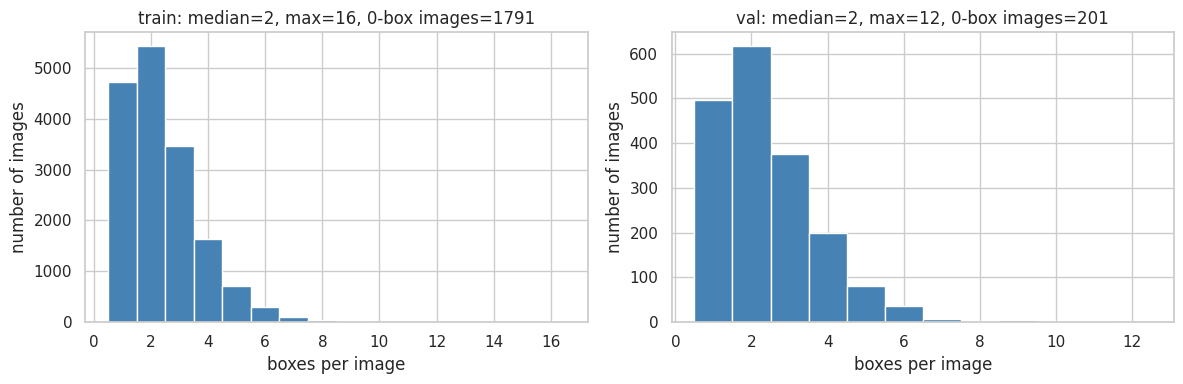

In [8]:
all_images = {s: {p.stem for p in list_files(s, "images")} for s in SPLITS}
boxes_per_image = boxes.groupby(["split", "image_id"]).size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, s in zip(axes, SPLITS):
    imgs_with_boxes = set(boxes.loc[boxes["split"] == s, "image_id"].unique())
    n_zero = len(all_images[s] - imgs_with_boxes)
    vals = boxes_per_image[s].values
    ax.hist(vals, bins=range(1, int(vals.max()) + 2), align="left", color="steelblue")
    ax.set_title(f"{s}: median={np.median(vals):.0f}, max={vals.max()}, 0-box images={n_zero}")
    ax.set_xlabel("boxes per image")
    ax.set_ylabel("number of images")
plt.tight_layout()
plt.show()


## 5. Bounding box geometry

Size, area, and aspect-ratio distributions (all in normalized [0, 1] coordinates).

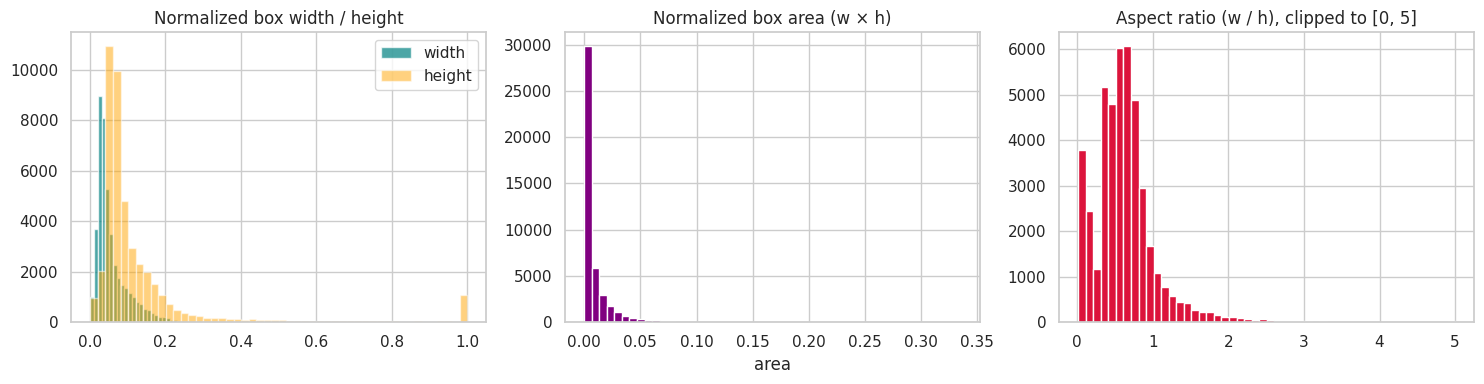

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(boxes["w"], bins=50, color="teal", alpha=0.7, label="width")
axes[0].hist(boxes["h"], bins=50, color="orange", alpha=0.5, label="height")
axes[0].set_title("Normalized box width / height")
axes[0].legend()

axes[1].hist(boxes["area"], bins=50, color="purple")
axes[1].set_title("Normalized box area (w × h)")
axes[1].set_xlabel("area")

axes[2].hist(np.clip(boxes["aspect_ratio"], 0, 5), bins=50, color="crimson")
axes[2].set_title("Aspect ratio (w / h), clipped to [0, 5]")

plt.tight_layout()
plt.show()


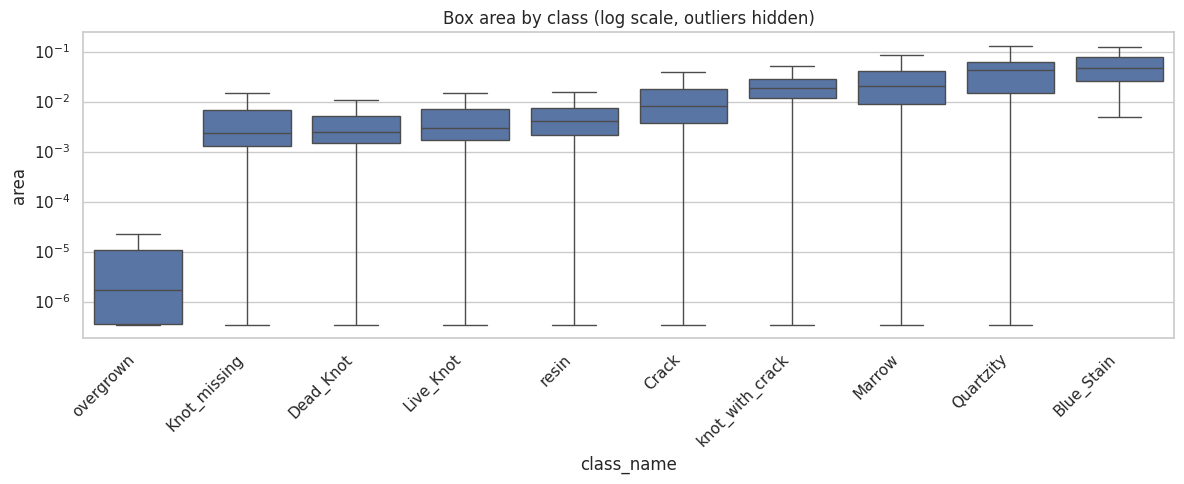

In [10]:
plt.figure(figsize=(12, 5))
order = boxes.groupby("class_name")["area"].median().sort_values().index
sns.boxplot(data=boxes, x="class_name", y="area", order=order, showfliers=False)
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Box area by class (log scale, outliers hidden)")
plt.tight_layout()
plt.show()


## 6. Class co-occurrence

How often two defect classes appear together on the same image.

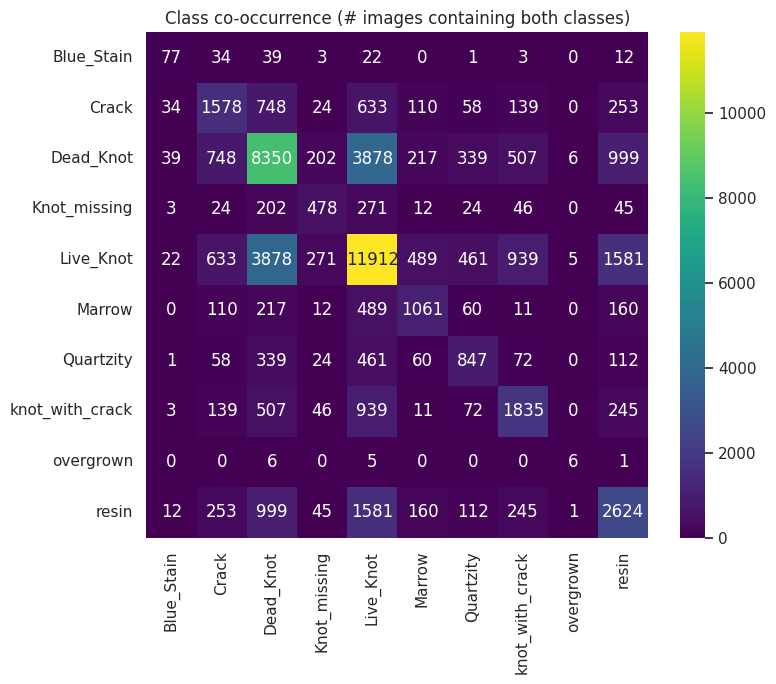

In [11]:
image_classes = boxes.groupby(["split", "image_id"])["class_name"].apply(lambda s: sorted(set(s)))

cooc = pd.DataFrame(0, index=CLASS_NAMES, columns=CLASS_NAMES)
for classes in image_classes:
    for c1 in classes:
        for c2 in classes:
            cooc.loc[c1, c2] += 1

plt.figure(figsize=(8, 7))
sns.heatmap(cooc, annot=True, fmt="d", cmap="viridis")
plt.title("Class co-occurrence (# images containing both classes)")
plt.tight_layout()
plt.show()


## 7. Image-level properties

Resolution is checked across **every** image (cheap — reads only the JPEG header).
Brightness and blur require a full decode, so those are computed on a random sample per split.


In [12]:
res_rows = [
    {"split": s, "width": im.width, "height": im.height}
    for s in SPLITS
    for p in list_files(s, "images")
    for im in [Image.open(p)]
]
res_df = pd.DataFrame(res_rows)
res_df.groupby("split")[["width", "height"]].describe()


width                                                                 \
         count         mean       std     min     25%     50%     75%     max   
split                                                                           
train  18248.0  2799.760960  3.344256  2708.0  2800.0  2800.0  2800.0  2800.0   
val     2028.0  2799.635602  4.231679  2724.0  2800.0  2800.0  2800.0  2800.0   

        height                                                       
         count    mean  std     min     25%     50%     75%     max  
split                                                                
train  18248.0  1024.0  0.0  1024.0  1024.0  1024.0  1024.0  1024.0  
val     2028.0  1024.0  0.0  1024.0  1024.0  1024.0  1024.0  1024.0

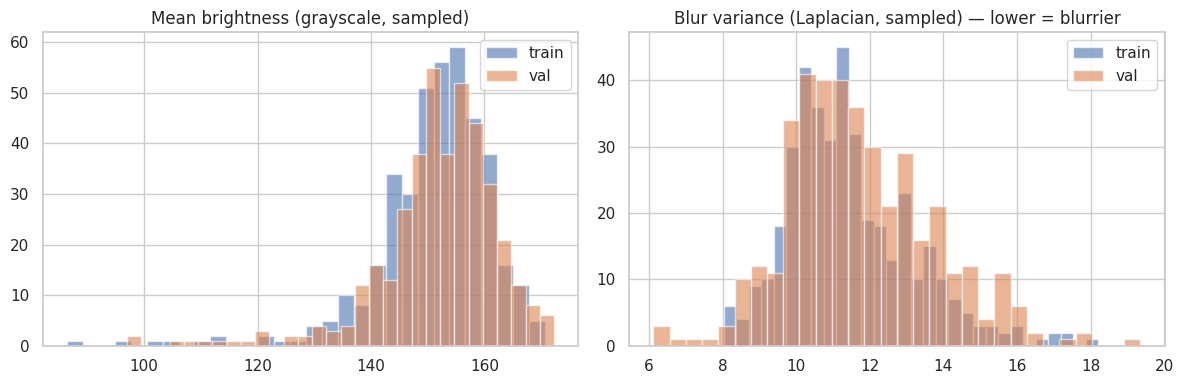

brightness                                                            \
           count        mean        std        min         25%         50%   
split                                                                        
train      400.0  151.167192  10.517571  86.382018  146.383088  152.547984   
val        400.0  151.792922  10.765294  96.972830  147.629925  153.186123   

                              blur_variance                                 \
              75%         max         count       mean       std       min   
split                                                                        
train  157.900290  170.705358         400.0  11.455326  1.735498  8.035509   
val    158.516829  172.276885         400.0  11.729242  1.995148  6.118075   

                                                   
             25%        50%        75%        max  
split                                              
train  10.263240  11.174698  12.445977  18.200003  
val    10.392259  11.452395  13.000187  19.353327

In [13]:
N_SAMPLE = 400  # per split; full decode is too slow to run on all ~20k images

quality_rows = []
for s in SPLITS:
    files = list_files(s, "images")
    sample = random.sample(files, min(N_SAMPLE, len(files)))
    for p in sample:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        quality_rows.append({
            "split": s,
            "brightness": img.mean(),
            "blur_variance": cv2.Laplacian(img, cv2.CV_64F).var(),
        })

quality_df = pd.DataFrame(quality_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for s in SPLITS:
    sub = quality_df[quality_df["split"] == s]
    axes[0].hist(sub["brightness"], bins=30, alpha=0.6, label=s)
    axes[1].hist(sub["blur_variance"], bins=30, alpha=0.6, label=s)
axes[0].set_title("Mean brightness (grayscale, sampled)")
axes[1].set_title("Blur variance (Laplacian, sampled) — lower = blurrier")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

quality_df.groupby("split")[["brightness", "blur_variance"]].describe()


## 8. Sample images with bounding boxes

One example per class, boxes drawn in red.

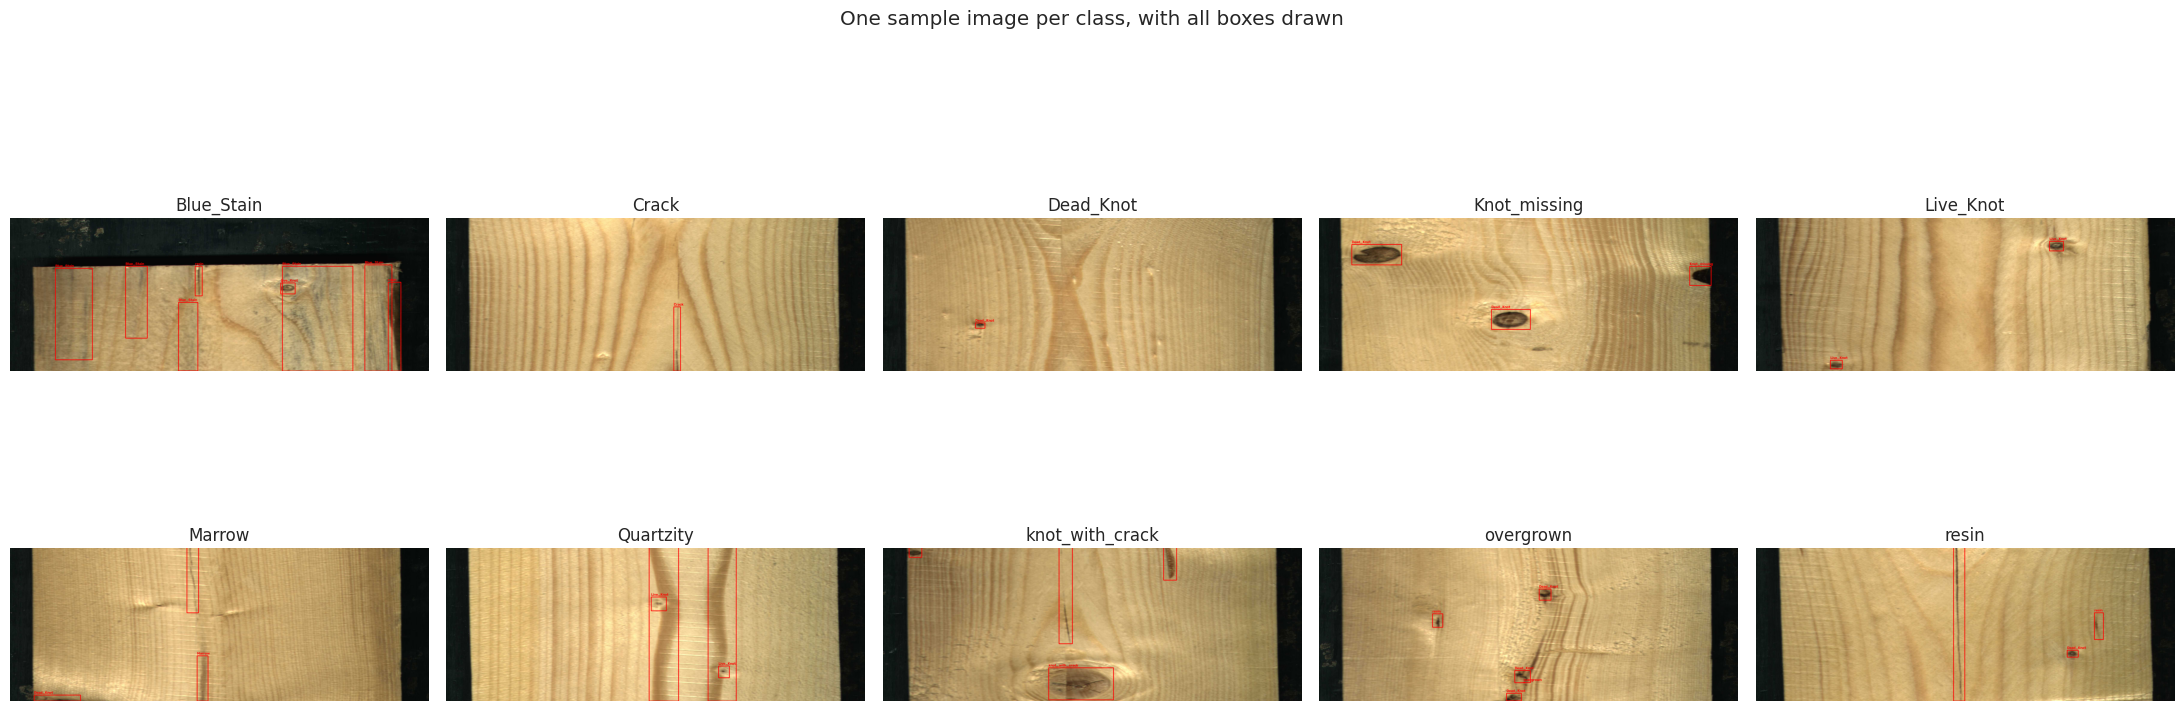

In [14]:
def draw_boxes(image_path, label_path):
    img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            cls_idx, xc, yc, bw, bh = map(float, line.split())
            cls_idx = int(cls_idx)
            x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
            x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.putText(img, CLASS_NAMES[cls_idx], (x1, max(y1 - 8, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    return img


fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, cls_name in zip(axes.flat, CLASS_NAMES):
    cls_rows = boxes[boxes["class_name"] == cls_name]
    if cls_rows.empty:
        ax.axis("off")
        continue
    row = cls_rows.sample(1, random_state=RNG_SEED).iloc[0]
    img_path = DATASET_DIR / "images" / row["split"] / f"{row['image_id']}.jpg"
    lbl_path = DATASET_DIR / "labels" / row["split"] / f"{row['image_id']}.txt"
    ax.imshow(draw_boxes(img_path, lbl_path))
    ax.set_title(cls_name)
    ax.axis("off")
plt.suptitle("One sample image per class, with all boxes drawn")
plt.tight_layout()
plt.show()


## 9. Object scale / shape clustering

`yolov8_CDC` is anchor-free (decoupled head, distribution focal loss) like stock YOLOv8, so this is
**not** an anchor-box config step. It's a k-means clustering of box shapes at a reference training
resolution, useful for judging whether small objects need a larger `imgsz`, and for sanity-checking
mosaic/scale augmentation ranges.


Box-shape clusters at imgsz=640 (w, h in px), sorted by area:
  (  22.5,   38.1) px   aspect=0.59
  (  52.2,   76.2) px   aspect=0.68
  (  23.1,  180.1) px   aspect=0.13
  (  28.9,  366.6) px   aspect=0.08
  ( 114.5,  112.7) px   aspect=1.02
  (  35.9,  619.9) px   aspect=0.06


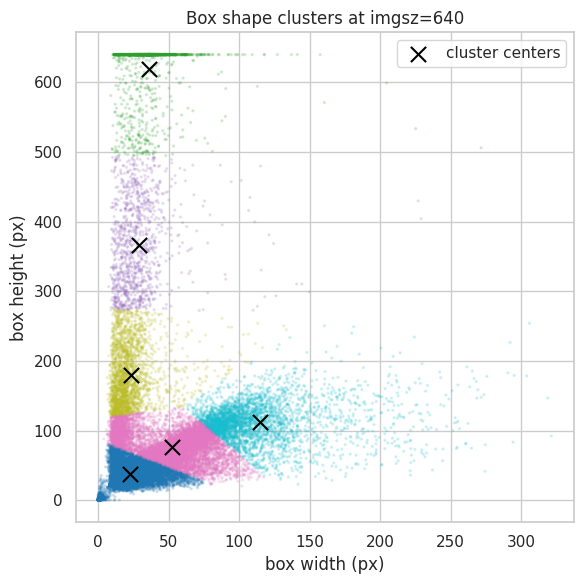

In [15]:
IMGSZ_REF = 640  # matches run_all.sh's default training image size

wh = boxes[["w", "h"]].values * IMGSZ_REF
k = 6
km = KMeans(n_clusters=k, n_init=10, random_state=RNG_SEED).fit(wh)
order = np.argsort(km.cluster_centers_[:, 0] * km.cluster_centers_[:, 1])
centers = km.cluster_centers_[order]

print(f"Box-shape clusters at imgsz={IMGSZ_REF} (w, h in px), sorted by area:")
for w, h in centers:
    print(f"  ({w:6.1f}, {h:6.1f}) px   aspect={w / h:.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(wh[:, 0], wh[:, 1], s=2, alpha=0.15, c=km.labels_, cmap="tab10")
plt.scatter(centers[:, 0], centers[:, 1], c="black", marker="x", s=120, label="cluster centers")
plt.xlabel("box width (px)")
plt.ylabel("box height (px)")
plt.title(f"Box shape clusters at imgsz={IMGSZ_REF}")
plt.legend()
plt.tight_layout()
plt.show()


## Summary & recommendations

Fill in after running the cells above — the numbers below are placeholders to replace with the
actual printed values once executed:

- **Size**: `{n_train}` train / `{n_val}` val images, `{n_boxes}` total boxes across `{n_classes}` classes.
- **Class imbalance**: largest/smallest class ratio from §3 — if it's large (>10x), consider
  class-weighted loss, oversampling rare classes, or targeted augmentation for them.
- **Split stratification**: §3's per-class train/val percentage gap — a few classes with a large gap
  mean val-set metrics for those classes will be noisy on this small a set.
- **Multi-object images**: §4's boxes-per-image distribution — if most images have several
  overlapping/adjacent defects, NMS and IoU thresholds during training deserve a closer look.
- **Object scale**: §9's cluster spread — if many boxes are small relative to `imgsz=640`, either
  raise `imgsz` or verify the CDC backbone's P3 stride still resolves them.
- **Image quality**: §7's brightness/blur outliers are candidates for manual inspection — very dark
  or very blurry samples may be mislabeled or worth excluding.

This notebook only reads the already-downloaded `wood_defects_dataset/` — no Hugging Face network
access needed, so it also works unmodified once that folder is copied over to Metacentrum.
